# In this notebook, we will explore the use of a Graph-VAE for our task.
We will build off of the existing model based on the Gómez-Bombarelli / `molecular-vae` style (conv encoder + GRU decoder).

## Imports

In [9]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Sequence

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Chemistry (RDKit)
from rdkit import Chem
from rdkit.Chem import Draw

import selfies as sf
from tqdm.auto import tqdm

SEED = 42
MAX_LEN = 120  # max SELFIES token length before EOS
VAL_FRAC = 0.10
TEST_FRAC = 0.10

LATENT_DIM = 292
EPOCHS = 20
BATCH_SIZE = 128
LR = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)

device: mps
torch: 2.10.0
selfies: 2.1.1


In [5]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH, TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))


# tox21 is loaded for later post-training only (not used for pretraining here)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

print(f"ChemBL unique SMILES: {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:   {len(zinc_smiles):,}")
print(f"tox21 train/val/test: {len(tox21_train_smiles):,} / {len(tox21_val_smiles):,} / {len(tox21_test_smiles):,}")

ChemBL unique SMILES: 23,871
Zinc unique SMILES:   249,455
tox21 train/val/test: 6,258 / 782 / 783


## Split Data

In [6]:
def filter_smiles_len(smiles_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in smiles_list if len(s) <= max_len]

pretrain_smiles = filter_smiles_len(pretrain_smiles, max_len=MAX_LEN)

train_smiles, temp_smiles = train_test_split(
    pretrain_smiles, test_size=VAL_FRAC + TEST_FRAC, random_state=SEED, shuffle=True
)

# split temp into val/test in the right proportion
val_ratio_in_temp = VAL_FRAC / (VAL_FRAC + TEST_FRAC)
val_smiles, test_smiles = train_test_split(
    temp_smiles, test_size=(1 - val_ratio_in_temp), random_state=SEED, shuffle=True
)

print(
    f"filtered combined split sizes: train={len(train_smiles):,}, "
    f"val={len(val_smiles):,}, test={len(test_smiles):,}"
)

filtered combined split sizes: train=218,058, val=27,257, test=27,258


## Graph Featurizer

In [20]:
# Build atom vocabulary
def build_atom_vocab(smiles_list):
    atom_symbols = set()
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        for atom in mol.GetAtoms():
            atom_symbols.add(atom.GetSymbol())
    return sorted(atom_symbols) + ["Unknown"]

We'll start with a simple graph featurizer that one hot encodes atom type as node features, and uses bond type as edge feature.

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Sequence

import torch
from rdkit import Chem


def one_hot_encoding(x: Any, allowable_set: Sequence[Any]) -> list[float]:
    """
    Map x to a one-hot vector over allowable_set.

    If x is not present, it is mapped to the final entry in allowable_set.
    This keeps the function easy to extend with an "Unknown" bucket.
    """
    if x not in allowable_set:
        x = allowable_set[-1]
    return [1.0 if x == s else 0.0 for s in allowable_set]


@dataclass
class GraphData:
    """
    Minimal graph container for one molecule.

    Attributes
    ----------
    smiles:
        Original SMILES string.
    x:
        Node feature matrix with shape [num_atoms, num_atom_features].
    edge_index:
        Edge list with shape [2, num_edges]. We store both directions.
    edge_attr:
        Edge feature matrix with shape [num_edges, num_bond_features].
    atom_symbols:
        Raw atom symbols in RDKit atom order for easy debugging.
    """

    smiles: str
    x: torch.Tensor
    edge_index: torch.Tensor
    edge_attr: torch.Tensor
    atom_symbols: list[str]

    @property
    def num_nodes(self) -> int:
        return int(self.x.size(0))

    @property
    def num_edges(self) -> int:
        return int(self.edge_index.size(1))


class SimpleGraphFeaturizer:
    """
    Turn a SMILES string into a simple molecular graph.

    Node features:
        One-hot atom symbol.

    Edge features:
        One-hot bond type.
    """

    def __init__(
        self,
        atom_types: list[str] | None = None,
        bond_types: list[Any] | None = None,
    ) -> None:
        self.atom_types = atom_types or [
            "C",
            "N",
            "O",
            "S",
            "F",
            "Cl",
            "Br",
            "I",
            "P",
            "Unknown",
        ]

        self.bond_types = bond_types or [
            Chem.rdchem.BondType.SINGLE,
            Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE,
            Chem.rdchem.BondType.AROMATIC,
            "Unknown",
        ]

    def __call__(self, smiles: str) -> GraphData:
        return self.featurize_smiles(smiles)

    def featurize_smiles(self, smiles: str) -> GraphData:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Could not parse SMILES: {smiles}")

        atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]

        xs: list[list[float]] = []
        for atom in mol.GetAtoms():
            xs.append(one_hot_encoding(atom.GetSymbol(), self.atom_types))

        x = torch.tensor(xs, dtype=torch.float)

        edge_indices: list[list[int]] = []
        edge_attrs: list[list[float]] = []

        for bond in mol.GetBonds():
            u = bond.GetBeginAtomIdx()
            v = bond.GetEndAtomIdx()
            bond_feat = one_hot_encoding(bond.GetBondType(), self.bond_types)

            edge_indices.append([u, v])
            edge_attrs.append(bond_feat)

            edge_indices.append([v, u])
            edge_attrs.append(bond_feat)

        if edge_indices:
            edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, len(self.bond_types)), dtype=torch.float)

        return GraphData(
            smiles=smiles,
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            atom_symbols=atom_symbols,
        )


In [18]:
atom_types = build_atom_vocab(train_smiles)
featurizer = SimpleGraphFeaturizer(atom_types=atom_types)

for smiles in train_smiles:
    data = featurizer(smiles)

example smiles: O=C(NCCN1CCOCC1)NCC1(Sc2ccccc2)CC1
atom symbols: ['O', 'C', 'N', 'C', 'C', 'N', 'C', 'C', 'O', 'C', 'C', 'N', 'C', 'C', 'S', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
x shape: (23, 14)
edge_index shape: (2, 50)
edge_attr shape: (50, 5)


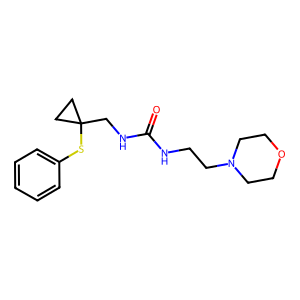

In [22]:
sample_graph = featurizer(train_smiles[0])

print("example smiles:", sample_graph.smiles)
print("atom symbols:", sample_graph.atom_symbols)
print("x shape:", tuple(sample_graph.x.shape))
print("edge_index shape:", tuple(sample_graph.edge_index.shape))
print("edge_attr shape:", tuple(sample_graph.edge_attr.shape))

mol = Chem.MolFromSmiles(sample_graph.smiles)
img = Draw.MolToImage(mol, size=(300, 300))
display(img)

### Sanity Check - What is in the x tensor?

x: Node feature matrix [23 x 14]
- This molecule has 23 atoms in it
- Each atom is represented with a one-hot vector, that is 14 length (based on the vocab size)

x[i]: feature VECTOR for one atom

edge_index [2 x 50]:
- Tells us graph connectivity
- 50 directed edges (25 bonds total)
- Rows: Start atom, End atom
- Ex: edge_index[:, k] = [source_node, target_node]

edge_attr [50 x 5]:

